# Minibatch version of Tutorial 1: Integrating human and macaque DLPFC slices (10x Visium, Stereo-seq)](./Tutorials/Tutorial1_DLPFC.ipynb)
  

## Dataset link
https://drive.google.com/file/d/1FEe-z19EBzYoL0qMylIgSQO4t8X0vOXF/view?usp=drive_link

## GPU memory requirements
4.2GB

## Running time


## Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
sys.path.append('../')
import STACAME
import os
# Modify the R path to your env R path
os.environ['R_HOME'] = "/data/zhanglab/zhangbiao/anaconda3/envs/stacame/lib/R"
os.environ['R_USER'] = "/data/zhanglab/zhangbiao/anaconda3/envs/stacame/lib/python3.11/site-packages/rpy2"
import rpy2.robjects as robjects
import rpy2.robjects.numpy2ri

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scipy.linalg
from scipy.sparse import csr_matrix
import pandas as pd
import torch
from STACAME.analysis import merge_embedding, clustering_umap_spatial
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score as ari_score
import seaborn as sns
import colorcet as cc

## Process of datasets

In [3]:
root_data_path = './Data/1_DLPFC/'
Gene_map_raw_path = './Data/1_DLPFC/Macaque_Human.tsv'
rad_cutoff_dict = {'Macaque':210, 'Human':250}
species_section_ids = {'Macaque':['macaque_T127_DLPFC'],
                       'Human':['human_151673_modified']}
species_ortholog_column_dict = {'Macaque':'Gene name', 
                                'Human':'Human gene name'}
species_ortholog_type_dict = {'Human':'Human homology type'}
species_id_map = {'Macaque':0, 'Human':1}


STACAME_processer = STACAME.STACAME_processer(root_data_path=root_data_path,
                 Gene_map_raw_path=Gene_map_raw_path, 
                 species_section_ids = species_section_ids, 
                 species_ortholog_column_dict = species_ortholog_column_dict, 
                 species_ortholog_type_dict = species_ortholog_type_dict, 
                 species_id_map = species_id_map, 
                 rad_cutoff_dict = rad_cutoff_dict,
                 gene_cap_upper_dict = {'Macaque':'upper', 'Human':'upper'},
                 Down_sampling_adata = None, 
                 n_top_genes = 300, 
                 homo_n_top_genes = 5000, 
                 cross_species_neibors_K_mnn = 20, #100
                 total_normalize = {'Macaque':1e4, 'Human':1e4},
                 min_cells = 50, 
                 if_hvg_before_mnn = True, 
                 if_combat_mnn = False, 
                 if_pca_before_mnn = True, pca_dim_before_mnn = 64, if_return_concat_adata = True)
adata_dict, triplet_ind_species_dict, edge_ndarray_species, adata_whole = STACAME_processer.load_process_adata()

print(adata_whole)
sc.pp.highly_variable_genes(adata_whole, flavor='seurat_v3', n_top_genes=3000)
sc.tl.pca(adata_whole, svd_solver='arpack', n_comps=50)
adata_whole = adata_whole[:, adata_whole.var.highly_variable].copy()
adata_whole.X = scipy.sparse.csr_matrix(adata_whole.X)

self.rad_cutoff_dict: {'Macaque': {'macaque_T127_DLPFC': 210}, 'Human': {'human_151673_modified': 250}}
--------------------------Species-Macaque-------------------------------
Species: Macaque Section: macaque_T127_DLPFC
(18375, 2)
Before flitering:  (18375, 15096)
After flitering:  (18375, 10805)
Number of genes: 10805
Before flitering:  (18375, 15096)
After flitering:  (18375, 10805)
Number of hvgs: 5000
Number of common hvgs: 5000
--------------------------Species-Human-------------------------------
Species: Human Section: human_151673_modified
(3611, 2)
Before flitering:  (3611, 18002)
After flitering:  (3611, 13080)
Number of genes: 13080
Before flitering:  (3611, 18002)
After flitering:  (3611, 13080)
Number of hvgs: 5000
Number of common hvgs: 5000
Normalizing data and get spatial neigbors...
--------------------------Species-Macaque-------------------------------
---------Section-macaque_T127_DLPFC---------
------Calculating spatial graph...
Using Euclidean distance for spati

## Running STACAME

For Macaque, using 5251 genes for training.
Pretrain with STAligner...
Pretrain with STAGATE_multiple...


100%|██████████| 1000/1000 [01:20<00:00, 12.50it/s]


For Human, using 5251 genes for training.
Pretrain with STAligner...
Pretrain with STAGATE_multiple...


100%|██████████| 1000/1000 [00:23<00:00, 42.63it/s]


-------------------------------------------------------------------------------
Prepare joint training...


  0%|          | 0/800 [00:00<?, ?it/s]

Epoch    0 | Total: 41.7685 | MSE: 12.1852 | Cross-species Tri: 7.6277 | MMD: 9.4693 | GAN: -0.4758 | OT: 0.0000 | Manifold: 12.9621
(21986, 40)


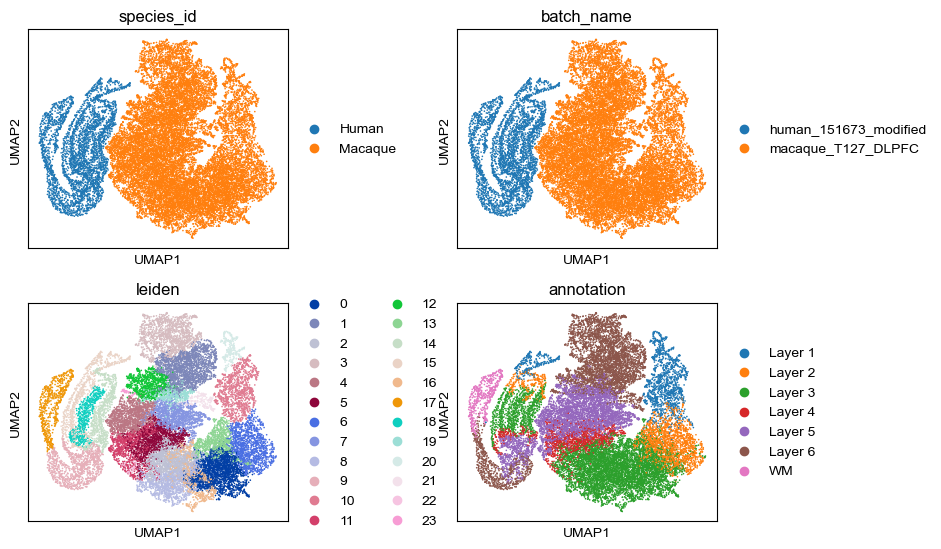

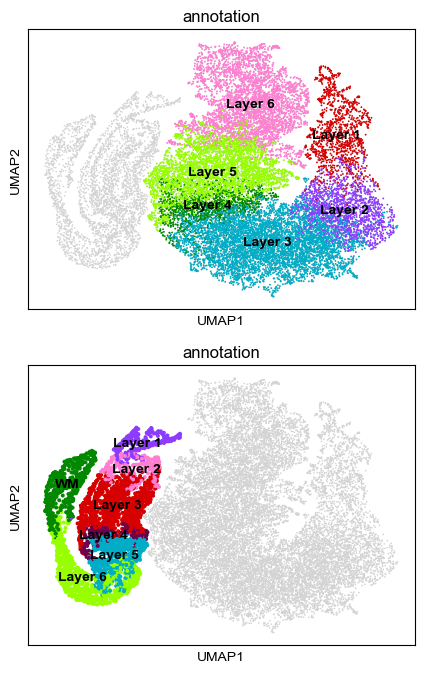

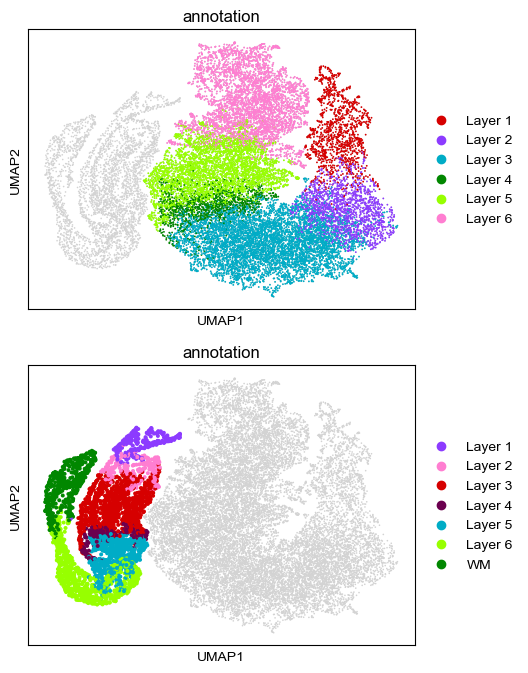

  3%|▎         | 25/800 [02:12<42:05,  3.26s/it]  

In [ ]:
%%time
import importlib
from STACAME import STACAME_subgraph_trainer
used_device = torch.device('cuda:5' if torch.cuda.is_available() else 'cpu')
pretrain_device = used_device

output_path = root_data_path + 'output_STACAME/'
if not os.path.exists(output_path):
    os.makedirs(output_path)

# ---------- New training with the class ----------
trainer = STACAME_subgraph_trainer(
    adata_species_dict=adata_dict,
    triplet_ind_species_dict=triplet_ind_species_dict,
    edge_ndarray_species=edge_ndarray_species,
    adata_whole=adata_whole,
    hidden_dims=[256, 40],
    stagate_epoch=1000,               # can also be a dict, e.g. {'Macaque':500, 'Human':500}
    n_epochs_species=800,
    lr_species=0.002,
    knn_neigh=10,
    device=used_device,
    pretrain_device=pretrain_device,
    mse_beta=1,
    tri_beta=0.5,
    mmd_beta=1,
    gan_beta=1,
    gan_epoch=3,
    mmd_batch_size=1024,
    concate_pca_dim=200,
    margin_species=1,
    if_knn_mnn_graph=False,
    if_batch_pretrain=False,            # full‑batch pretraining
    batch_size=1024,
    if_use_light_model=True,
    structure_beta=5,
    structure_sampling_ratio=1.0,       # default
    model_save_path = output_path,    # directory for saving best model
    if_return_loss=True,
    verbose=True)
# Run training; result contains (adata_species_dict, loss_dict) if if_return_loss=True
result = trainer.run()
# Access the outputs
adata_species_dict, loss_dict = result   # only if if_return_loss=True was set

# # ---------- Resume training from a checkpoint ----------
# trainer_resume = STACAME_subgraph_trainer(
#     adata_species_dict=adata_dict,
#     triplet_ind_species_dict=triplet_ind_species_dict,
#     edge_ndarray_species=edge_ndarray_species,
#     adata_whole=adata_whole,
#     hidden_dims=[256, 30],
#     stagate_epoch=500,
#     n_epochs_species=1000,
#     lr_species=0.005,
#     key_added='STACAME',
#     knn_neigh=4,
#     device=used_device,
#     pretrain_device=pretrain_device,
#     mse_beta=1,
#     tri_beta=1,
#     mmd_beta=5,
#     gan_beta=5,
#     gan_epoch=3,
#     mmd_batch_size=1024,
#     concate_pca_dim=128,
#     margin_species=1,
#     if_knn_mnn_graph=True,
#     if_batch_pretrain=False,
#     batch_size=2048,
#     if_use_light_model=True,
#     structure_beta=5,
#     structure_sampling_ratio=1.0,
#     model_save_path= output_path,
#     resume_from_checkpoint= output_path + 'checkpoints/best_checkpoint.pth',   # load saved state
#     if_return_loss=True,
#     verbose=True,
#     random_seed=666
# )

# result_resume = trainer_resume.run()
# adata_species_dict_resumed, loss_dict_resumed = result_resume

## Save embeddings

In [ ]:
output_path = root_data_path + 'output_STACAME_minibatch/'
if not os.path.exists(output_path):
    os.makedirs(output_path)

adata_embedding = merge_embedding(adata_dict, key_umap = 'STACAME')
adata_embedding.obs['region_name'] = adata_embedding.obs['annotation']
adata_embedding.write(output_path + 'adata_embedding.h5ad')

In [ ]:
root_data_path = './Data/1_DLPFC/'
output_path = root_data_path + 'output_STACAME_minibatch/'
adata_embedding = sc.read_h5ad(output_path + 'adata_embedding.h5ad')

## Visualization of shared mclust clusters and ARI

In [ ]:
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.size'] = 10
fig_format = 'png'
fig_dpi = 500
annotation_num = 7

fig_save_path = output_path

num_clusters =annotation_num
print(f'Mclust {num_clusters} clusters...')

STACAME.mclust_R(adata_embedding, num_cluster=num_clusters, used_obsm='STACAME')

Batch_list = []

for species_id in species_section_ids.keys():
    adata_temp = adata_embedding[adata_embedding.obs['species_id'].isin([species_id])]
    Batch_list.append(adata_temp)

species_list = list(species_section_ids.keys())
spot_size = 120
title_size = 10
ARI_list = []
for bb in range(2):
    ARI_list.append(round(ari_score(Batch_list[bb].obs['annotation'], Batch_list[bb].obs['mclust']), 2))

fig, ax = plt.subplots(2, 2, figsize=(10, 8), gridspec_kw={'wspace': 0.3, 'hspace': 0.1})

clust_list = list(set(list(Batch_list[0].obs['mclust'].unique()) + list(Batch_list[1].obs['mclust'].unique())))
color_list = sns.color_palette(cc.glasbey, n_colors=len(clust_list))
clust_palette = {k:v for k,v in zip(clust_list, color_list)}
palette = {k:clust_palette[k] for k in Batch_list[0].obs['mclust'].unique()}
_sc_0 = sc.pl.spatial(Batch_list[0], img_key=None, color=['mclust'], title=['mclust'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[0][0], frameon=False,
                      spot_size=spot_size, palette=palette)
_sc_0[0].set_title("ARI=" + str(ARI_list[0]), size=title_size)
color_list = sns.color_palette(cc.glasbey, n_colors=len(Batch_list[0].obs['annotation'].unique()))
#palette = {k:v for k,v in zip(Batch_list[0].obs['annotation'].unique(), color_list)}
region_list =  ['Layer 1', 'Layer 2', 'Layer 3', 'Layer 4', 'Layer 5','Layer 6']
color_list = sns.color_palette(cc.glasbey, n_colors=len(region_list))
palette = {k:v for k,v in zip([x for x in region_list], color_list)}
_sc_1 = sc.pl.spatial(Batch_list[0], img_key=None, color=['annotation'], title=[species_list[0] + ' annotation'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[0][1], frameon=False,
                      spot_size=spot_size, palette=palette)
palette = {k:clust_palette[k] for k in Batch_list[1].obs['mclust'].unique()}

spot_size = 150
_sc_2 = sc.pl.spatial(Batch_list[1], img_key=None, color=['mclust'], title=['mclust'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[1][0], frameon=False,
                      spot_size=spot_size, palette=palette)
_sc_2[0].set_title("ARI=" + str(ARI_list[1]), size=title_size)
color_list = sns.color_palette(cc.glasbey, n_colors=len(Batch_list[1].obs['annotation'].unique()))
#palette = {k:v for k,v in zip(Batch_list[1].obs['annotation'].unique(), color_list)}
region_list = ['Layer 1', 'Layer 2', 'Layer 3', 'Layer 4', 'Layer 5','Layer 6', 'WM']
color_list = sns.color_palette(cc.glasbey, n_colors=len(region_list))
palette = {k:v for k,v in zip([x for x in region_list], color_list)}
_sc_3 = sc.pl.spatial(Batch_list[1], img_key=None, color=['annotation'], title=[species_list[1] + ' annotation'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[1][1], frameon=False, 
                      spot_size=spot_size, palette=palette)

if not os.path.exists(fig_save_path):
    os.makedirs(fig_save_path)
plt.savefig(fig_save_path + 'common_mclust.png', format=fig_format, dpi=fig_dpi)
plt.show()

## UMAP of embeddings

In [ ]:
from STACAME.analysis import get_alignment_score, convert_dict2adata
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='white')
TINY_SIZE = 11 # 39
SMALL_SIZE = 11  # 42
MEDIUM_SIZE = 12  # 46
BIGGER_SIZE = 12  # 46

umap_neighbor = 30
umap_size_dict = {'Macaque':3, 'Human':6}
fig_format = 'jpg'
macaque_color = '#CCAE3D' #5D8AEF'#'#4472C4'
human_color = '#FE1613'#'#FE1613'#'#CCAE3D'#'#FE1613' #'#C94799'#'#ED7D31'
save_path = './output_STACAME_minibatch/figs/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

fig_dpi = 400
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labelsc
plt.rc('xtick', labelsize=TINY_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=TINY_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']


palette = {'Macaque':macaque_color, 'Human':human_color}

#adata_embedding = ad.concat([adata_macaque_embedding, adata_human_embedding])
adata_embedding.obs['dataset'] = adata_embedding.obs['species_id']

sc.tl.pca(adata_embedding, svd_solver='arpack', n_comps=10)
sc.pp.neighbors(adata_embedding, n_neighbors=umap_neighbor, metric='cosine',
                use_rep='X')
sc.tl.umap(adata_embedding)

adata_macaque_embedding = adata_embedding[adata_embedding.obs['dataset'].isin(['Macaque'])]
adata_human_embedding = adata_embedding[adata_embedding.obs['dataset'].isin(['Human'])]

adata_umap_size_list = [umap_size_dict[x] for x in adata_embedding.obs['dataset']]


with plt.rc_context({"figure.figsize": (3, 2.5), "figure.dpi": (fig_dpi)}):
    sc.pl.umap(adata_macaque_embedding, color=['region_name'], return_fig=True, legend_loc='right margin', size=3).savefig(
        save_path + 'umap_macaque.' + fig_format, format=fig_format)
# plt.subplots_adjust(left = 0.1, right=5)
#
sc.pp.neighbors(adata_human_embedding, n_neighbors=umap_neighbor, metric='cosine', use_rep='X')
sc.tl.umap(adata_human_embedding)

with plt.rc_context({"figure.figsize": (3, 2.5), "figure.dpi": (fig_dpi)}):
    # sc.set_figure_params(dpi_save=200)
    sc.pl.umap(adata_human_embedding, color=['region_name'], return_fig=True, size=3,
               legend_loc='right margin').savefig(
        save_path + 'umap_human.' + fig_format, format=fig_format)
# plt.subplots_adjust(left=0.1, right=5)
# plt.tight_layout()
rcParams["figure.subplot.left"] = 0.2
rcParams["figure.subplot.right"] = 0.9



rcParams["figure.subplot.left"] = 0.1
rcParams["figure.subplot.right"] = 0.68#0.6545
with plt.rc_context({"figure.figsize": (4, 3), "figure.dpi": (fig_dpi)}):
    fg = sc.pl.umap(adata_embedding, color=['dataset'], return_fig=True, legend_loc='right margin', title='', size= adata_umap_size_list, palette=palette)
    plt.title('')
    fg.savefig(save_path + 'umap_dataset_after_integration_rightmargin.' + fig_format, format=fig_format)


rcParams["figure.subplot.right"] = 0.9
#rcParams["figure.subplot.bottom"] = 0.1
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (fig_dpi)}):
    fg = sc.pl.umap(adata_embedding, color=['dataset'], return_fig=True, legend_loc=None, title='', size= adata_umap_size_list, palette=palette)
    plt.title('')
    fg.savefig(save_path + 'umap_dataset_after_integration.' + fig_format, format=fig_format)